In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("All imports successful!")

All imports successful!


In [3]:
df = pd.read_csv('student_data.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


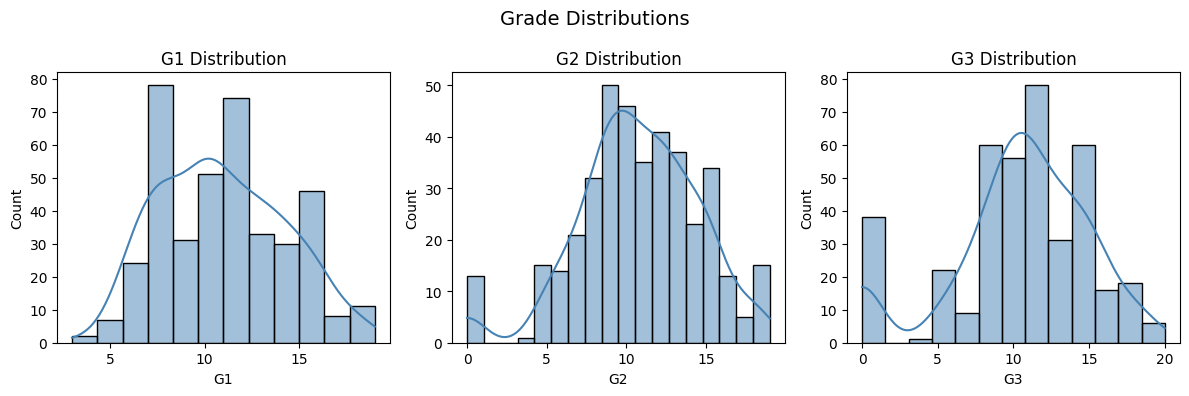

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['G1', 'G2', 'G3']):
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(f'{col} Distribution')
plt.suptitle('Grade Distributions', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12544\3065471706.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df, palette='Reds')


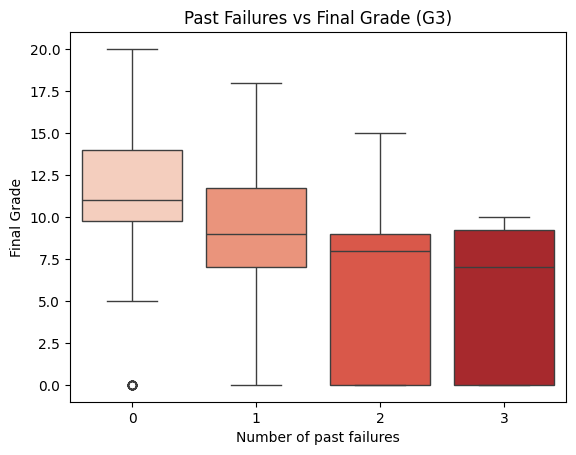

In [7]:
sns.boxplot(x='failures', y='G3', data=df, palette='Reds')
plt.title('Past Failures vs Final Grade (G3)')
plt.xlabel('Number of past failures')
plt.ylabel('Final Grade')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_12544\2713210298.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Greens')


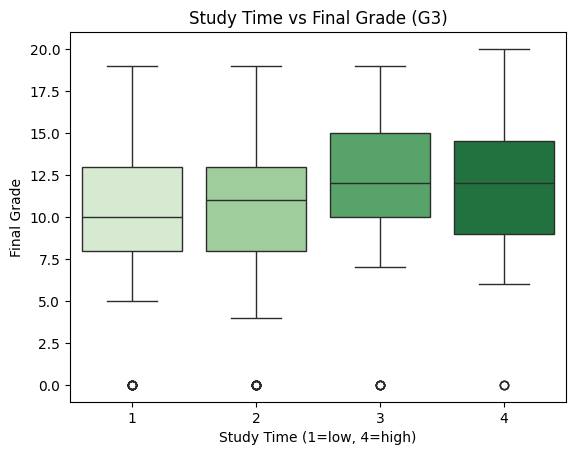

In [8]:
sns.boxplot(x='studytime', y='G3', data=df, palette='Greens')
plt.title('Study Time vs Final Grade (G3)')
plt.xlabel('Study Time (1=low, 4=high)')
plt.ylabel('Final Grade')
plt.show()

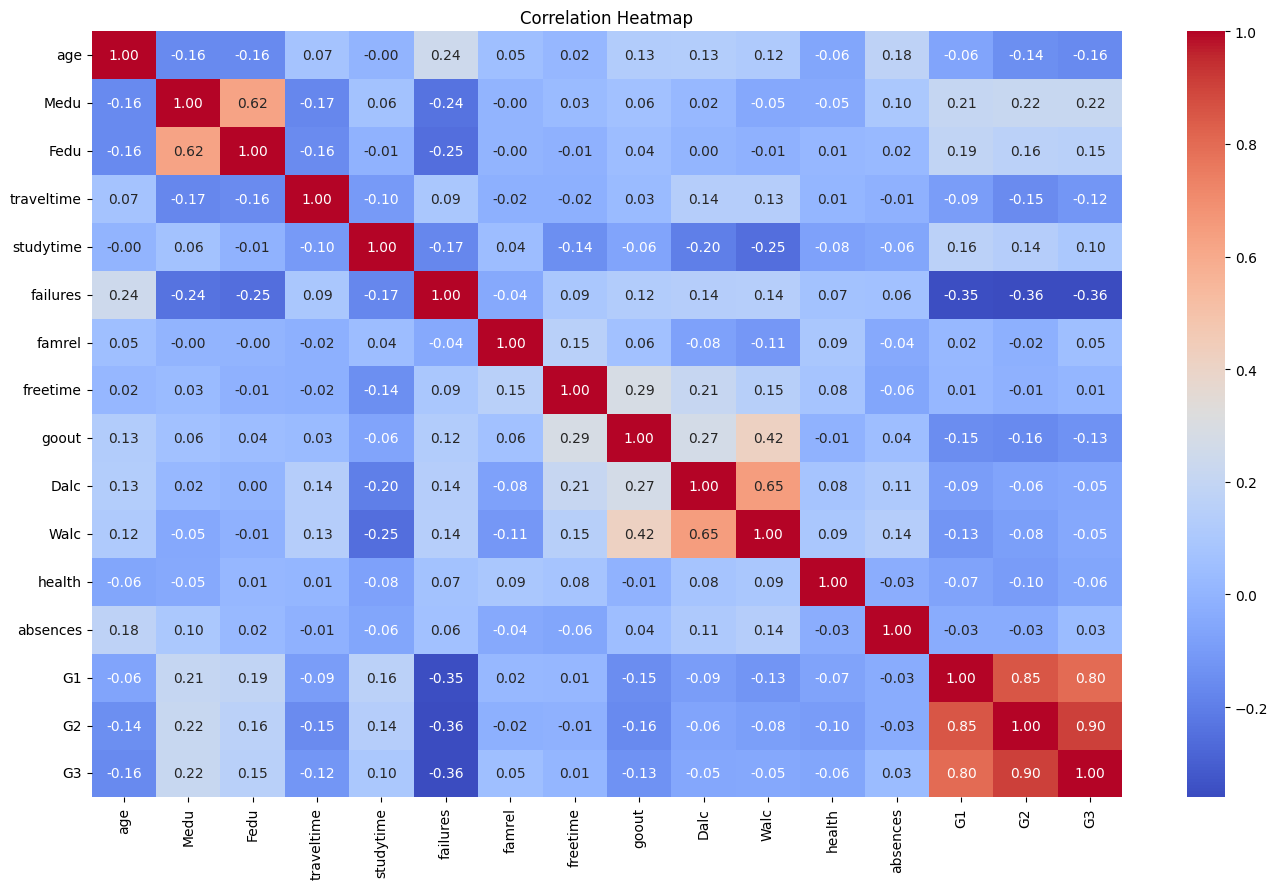

In [9]:
plt.figure(figsize=(14, 9))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
cat_cols = df.select_dtypes(include='object').columns
print("Columns being encoded:", list(cat_cols))

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("\nNew shape after encoding:", df_encoded.shape)

Columns being encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

New shape after encoding: (395, 42)


C:\Users\hp\AppData\Local\Temp\ipykernel_12544\3253282837.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [11]:
# First experiment — predict G3 WITHOUT using G1 and G2
y = df_encoded['G3']
X = df_encoded.drop(['G3', 'G1', 'G2'], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 39)
y shape: (395,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 316
Test rows: 79


In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("LINEAR REGRESSION (without G1, G2)")
print(f"  MAE : {mean_absolute_error(y_test, pred_lr):.2f}")
print(f"  R²  : {r2_score(y_test, pred_lr):.2f}")

LINEAR REGRESSION (without G1, G2)
  MAE : 3.40
  R²  : 0.14


In [14]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("DECISION TREE (without G1, G2)")
print(f"  MAE : {mean_absolute_error(y_test, pred_dt):.2f}")
print(f"  R²  : {r2_score(y_test, pred_dt):.2f}")

DECISION TREE (without G1, G2)
  MAE : 3.42
  R²  : 0.02


In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("RANDOM FOREST (without G1, G2)")
print(f"  MAE : {mean_absolute_error(y_test, pred_rf):.2f}")
print(f"  R²  : {r2_score(y_test, pred_rf):.2f}")

RANDOM FOREST (without G1, G2)
  MAE : 3.15
  R²  : 0.24


In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_dt),
        mean_absolute_error(y_test, pred_rf)
    ],
    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ]
})
print(results.round(3))

               Model    MAE  R2 Score
0  Linear Regression  3.395     0.141
1      Decision Tree  3.424     0.023
2      Random Forest  3.148     0.245


In [17]:
# Second experiment — WITH G1 and G2
y2 = df_encoded['G3']
X2 = df_encoded.drop(['G3'], axis=1)  # keep G1 and G2 this time

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print("X2 shape:", X2.shape)

X2 shape: (395, 41)


In [18]:
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
pred_lr2 = lr2.predict(X2_test)

dt2 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt2.fit(X2_train, y2_train)
pred_dt2 = dt2.predict(X2_test)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
pred_rf2 = rf2.predict(X2_test)

print("Models retrained with G1 and G2 included!")

Models retrained with G1 and G2 included!


In [19]:
results2 = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE without G1G2': [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_dt),
        mean_absolute_error(y_test, pred_rf)
    ],
    'MAE with G1G2': [
        mean_absolute_error(y2_test, pred_lr2),
        mean_absolute_error(y2_test, pred_dt2),
        mean_absolute_error(y2_test, pred_rf2)
    ],
    'R2 without G1G2': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ],
    'R2 with G1G2': [
        r2_score(y2_test, pred_lr2),
        r2_score(y2_test, pred_dt2),
        r2_score(y2_test, pred_rf2)
    ]
})
print(results2.round(3))

               Model  MAE without G1G2  MAE with G1G2  R2 without G1G2  \
0  Linear Regression             3.395          1.647            0.141   
1      Decision Tree             3.424          1.357            0.023   
2      Random Forest             3.148          1.165            0.245   

   R2 with G1G2  
0         0.724  
1         0.703  
2         0.815  


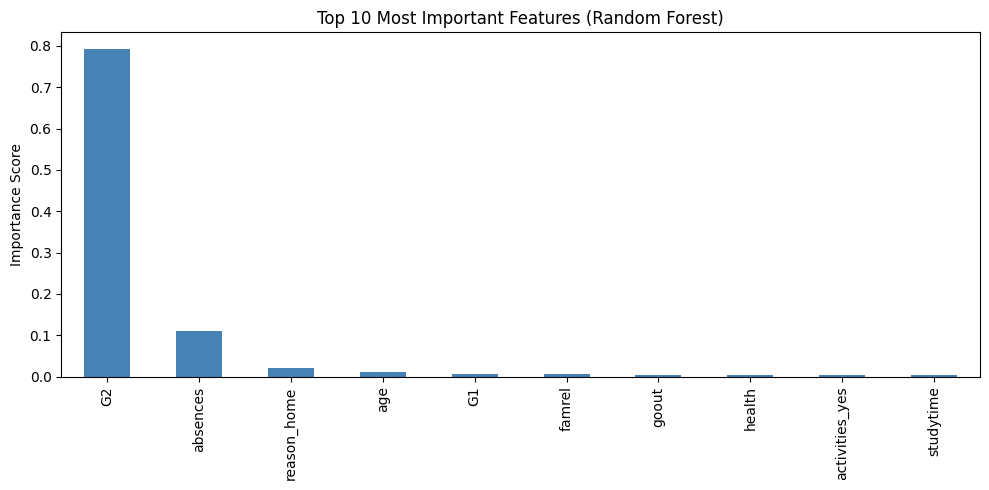

In [20]:
importances = pd.Series(rf2.feature_importances_, index=X2_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title('Top 10 Most Important Features (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()